# Demo: Aurora 1.5 on Foundry

This example submits an **Aurora 1.5** forecast to an Azure AI Foundry endpoint.
The fine-tuned Aurora 1.5 models extend the base Aurora model with:

- **26 surface-level variables** (including insolation)
- **36 static variables** (land-surface and vegetation fields)
- **Variable lead-time embeddings**, enabling hourly (sub-6-hour) output
- **7 output-only surface variables** (e.g. precipitation, wind gusts)
- **Model perturbations for ensemble prediction** in the `aurora-0.25-v1.5-ensemble` version

We download ERA5 data for 1 Jan 2023 at 0.25° resolution, build a `Batch`, and submit
it to the Foundry endpoint with hourly sub-steps, producing **24 hourly predictions**.

## Setup

Install the required packages:

In [ ]:
%pip install -q cdsapi matplotlib

In [ ]:
import logging
import warnings

warnings.filterwarnings("ignore")

logging.basicConfig(level=logging.WARNING, format="%(asctime)s [%(levelname)s] %(message)s")
logging.getLogger("aurora").setLevel(logging.INFO)

## Downloading the Data

Register an account with the [Climate Data Store](https://cds.climate.copernicus.eu/)
and create `$HOME/.cdsapirc`:

```
url: https://cds.climate.copernicus.eu/api
key: <API key>
```

Accept the terms of use on the
[ERA5 single-levels](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=download)
and
[ERA5 pressure-levels](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels?tab=download)
dataset pages.

In [ ]:
from pathlib import Path

import cdsapi

download_path = Path("~/downloads/era5_v1p5").expanduser()
download_path.mkdir(parents=True, exist_ok=True)

# ----- Surface-level variables (extended set for V1.5) -----
if not (download_path / "2023-01-01-surface-level.nc").exists():
    c = cdsapi.Client()
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "2m_temperature",
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
                "mean_sea_level_pressure",
                "2m_dewpoint_temperature",
                "total_column_water_vapour",
                "total_cloud_cover",
                "100m_u_component_of_wind",
                "100m_v_component_of_wind",
                "surface_pressure",
                "low_cloud_cover",
                "medium_cloud_cover",
                "high_cloud_cover",
                "skin_temperature",
                "soil_temperature_level_1",
                "volumetric_soil_water_layer_1",
                "sea_ice_cover",
                "snow_depth",
            ],
            "year": "2023",
            "month": "01",
            "day": "01",
            "time": ["00:00", "06:00", "12:00", "18:00"],
            "data_format": "netcdf",
        },
        str(download_path / "2023-01-01-surface-level.nc"),
    )
print("Surface-level variables downloaded!")

# ----- Atmospheric variables -----
if not (download_path / "2023-01-01-atmospheric.nc").exists():
    c = cdsapi.Client()
    c.retrieve(
        "reanalysis-era5-pressure-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "temperature",
                "u_component_of_wind",
                "v_component_of_wind",
                "specific_humidity",
                "geopotential",
            ],
            "pressure_level": [
                "50",
                "100",
                "150",
                "200",
                "250",
                "300",
                "400",
                "500",
                "600",
                "700",
                "850",
                "925",
                "1000",
            ],
            "year": "2023",
            "month": "01",
            "day": "01",
            "time": ["00:00", "06:00", "12:00", "18:00"],
            "data_format": "netcdf",
        },
        str(download_path / "2023-01-01-atmospheric.nc"),
    )
print("Atmospheric variables downloaded!")

## Downloading the Static Variables

Aurora V1.5 uses 36 static variables (land-sea mask, orography, vegetation fields,
soil types, etc.). These are provided in a pickle file alongside the model checkpoint.

In [ ]:
static_path = "aurora-0.25-v1.5-static.pickle"

## Preparing the Batch

We convert the downloaded data to an `aurora.Batch`. Aurora V1.5 requires:
- **18 input surface variables** (+ insolation, computed automatically)
- **36 static variables** (from the pickle file)
- **5 atmospheric variables** at 13 pressure levels

The 7 output-only surface variables are handled automatically by the model.

In [ ]:
import pickle
from datetime import datetime

import numpy as np
import torch
import xarray as xr

from aurora import Batch, Metadata
from aurora.insolation import insolation

surf_vars_ds = xr.open_dataset(download_path / "2023-01-01-surface-level.nc", engine="netcdf4")
atmos_vars_ds = xr.open_dataset(download_path / "2023-01-01-atmospheric.nc", engine="netcdf4")

# CDS NetCDF variable name -> Aurora canonical short name.
surf_name_map = {
    "t2m": "2t",
    "u10": "10u",
    "v10": "10v",
    "msl": "msl",
    "d2m": "2d",
    "tcwv": "tcwv",
    "tcc": "tcc",
    "u100": "100u",
    "v100": "100v",
    "sp": "sp",
    "lcc": "lcc",
    "mcc": "mcc",
    "hcc": "hcc",
    "skt": "skt",
    "stl1": "stl1",
    "swvl1": "swvl1",
    "siconc": "ci",
    "sd": "scaled_sd",
}

# Build surface variable tensors: select hours 00:00 and 06:00, insert batch dim.
surf_vars = {}
for nc_name, aurora_name in surf_name_map.items():
    data = surf_vars_ds[nc_name].values[:2][None]  # (1, 2, H, W)
    surf_vars[aurora_name] = torch.from_numpy(np.nan_to_num(data, nan=0.0).astype(np.float32))

# Compute and add insolation for the two input time steps.
lat = surf_vars_ds.latitude.values.astype(np.float32)
lon = surf_vars_ds.longitude.values.astype(np.float32)

input_times = [datetime(2023, 1, 1, 0), datetime(2023, 1, 1, 6)]
sol = np.stack(
    [insolation([t], lat, lon, enforce_2d=True)[0] for t in input_times],
    axis=0,
)
surf_vars["insolation"] = torch.from_numpy(sol[None].astype(np.float32))

# Build atmospheric variable tensors: (1, 2, 13, H, W).
levels = (50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000)
atmos_vars = {}
for nc_name, aurora_name in [("t", "t"), ("u", "u"), ("v", "v"), ("q", "q"), ("z", "z")]:
    data = atmos_vars_ds[nc_name].sel(pressure_level=list(levels)).values[:2][None]
    atmos_vars[aurora_name] = torch.from_numpy(np.nan_to_num(data, nan=0.0).astype(np.float32))

# Load static variables from the pickle file.
with open(static_path, "rb") as f:
    static_raw = pickle.load(f)
static_vars = {k: torch.from_numpy(v) for k, v in static_raw.items()}

# Longitude: ensure values are in [0, 360).
if surf_vars_ds.longitude.values.min() < 0:
    raise ValueError("Aurora expects longitude values to be in the range [0, 360).")

batch = Batch(
    surf_vars=surf_vars,
    static_vars=static_vars,
    atmos_vars=atmos_vars,
    metadata=Metadata(
        lat=torch.from_numpy(surf_vars_ds.latitude.values),
        lon=torch.from_numpy(surf_vars_ds.longitude.values),
        time=(input_times[1],),
        atmos_levels=levels,
    ),
)

print(
    f"Batch ready: {len(batch.surf_vars)} surf vars, "
    f"{len(batch.static_vars)} static vars, "
    f"{len(batch.atmos_vars)} atmos vars, "
    f"shape {batch.spatial_shape}"
)

## Submit to Azure AI Foundry

We connect to the Foundry endpoint and run **Aurora V1.5** for 4 main steps with
hourly sub-steps (`fine_lead_times=[1, 2, 3, 4, 5, 6]`), producing **24 hourly
predictions**.

The environment variables `FOUNDRY_ENDPOINT`, `FOUNDRY_TOKEN`, and `BLOB_URL_WITH_SAS`
must be set. See [the Foundry intro](intro.md) for details.

In [ ]:
import os

from aurora.foundry import BlobStorageChannel, FoundryClient, submit

foundry_client = FoundryClient(
    endpoint=os.environ["FOUNDRY_ENDPOINT"],
    token=os.environ["FOUNDRY_TOKEN"],
)
channel = BlobStorageChannel(os.environ["BLOB_URL_WITH_SAS"])

predictions = list(
    submit(
        batch,
        model_name="aurora-0.25-v1.5",
        num_steps=4,
        foundry_client=foundry_client,
        channel=channel,
        fine_lead_times=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0],
    )
)

print(f"Received {len(predictions)} hourly predictions.")

## Visualising the Results

We plot 2-metre temperature predictions at T+6h, T+12h, T+18h, and T+24h.

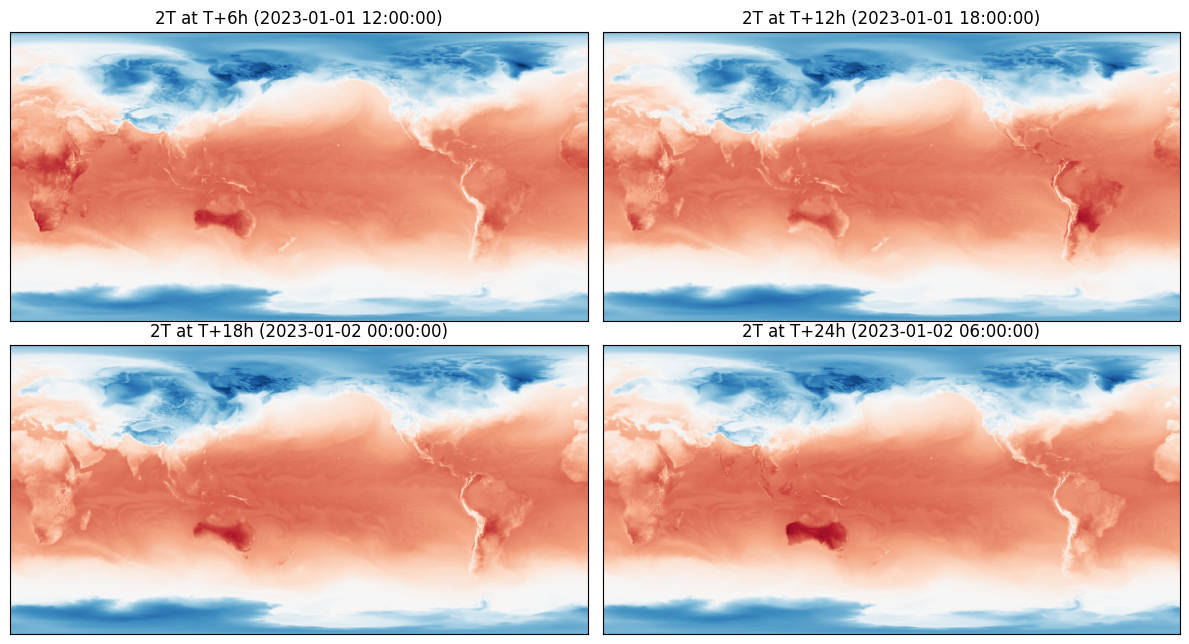

In [ ]:
import matplotlib.pyplot as plt

show_indices = [5, 11, 17, 23]  # T+6h, T+12h, T+18h, T+24h

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))

for ax, idx in zip(axes.flat, show_indices):
    pred = predictions[idx]
    lead_hours = idx + 1
    im = ax.imshow(pred.surf_vars["2t"][0, 0].numpy() - 273.15, vmin=-50, vmax=50, cmap="RdBu_r")
    ax.set_title(f"2T at T+{lead_hours}h ({pred.metadata.time[0]})")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

Aurora V1.5 also predicts output-only variables such as precipitation and wind gusts.
Here we plot the total precipitation (`scaled_tp_1h`) at T+12h:

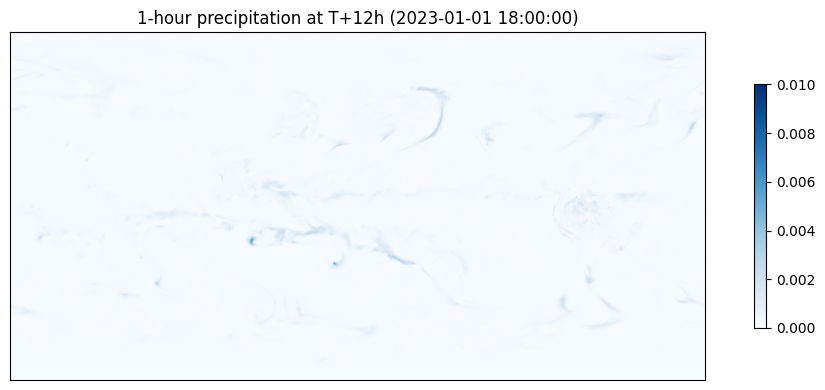

In [ ]:
pred_12h = predictions[11]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(
    pred_12h.surf_vars["scaled_tp_1h"][0, 0].numpy(),
    vmin=0,
    vmax=0.01,
    cmap="Blues",
)
ax.set_title(f"1-hour precipitation at T+12h ({pred_12h.metadata.time[0]})")
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()